In [18]:
# Libraries
# scipy, numpy, pandas, matplotlib, seaborn and scikit-learn

from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


# parameter tuning
from sklearn.preprocessing import StandardScaler

# Additional libraries

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error







In [5]:
data = '2_heart_Regression.csv'

In [6]:
df = pd.read_csv(data)
df.head(10)

,Unnamed: 0,biking,smoking,heart.disease
0,1,30.801246,10.896608,11.769423
1,2,65.129215,2.219563,2.854081
2,3,1.959665,17.588331,17.177803
3,4,44.800196,2.802559,6.816647
4,5,69.428454,15.974505,4.062224
5,6,54.403626,29.333176,9.550046
6,7,49.056162,9.060846,7.624507
7,8,4.784604,12.835021,15.854654
8,9,65.730788,11.991297,3.067462
9,10,35.257449,23.277683,12.098484


In [7]:
# train test split with cross validation
df = df.drop(columns = ['Unnamed: 0'])
y_values = df['heart.disease']
X_values = df.drop(columns=['heart.disease'])

X_train, X_test, y_train, y_test = train_test_split(X_values, y_values, test_size=.20, random_state=123)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

### Exploratory Data Analysis

In [8]:
df.head()

,biking,smoking,heart.disease
0,30.801246,10.896608,11.769423
1,65.129215,2.219563,2.854081
2,1.959665,17.588331,17.177803
3,44.800196,2.802559,6.816647
4,69.428454,15.974505,4.062224


In [9]:
df.describe()

,biking,smoking,heart.disease
count,498.000000,498.000000,498.000000
mean,37.788411,15.435034,10.174538
std,21.481519,8.289959,4.571874
min,1.119154,0.525850,0.551898
25%,20.204598,8.279776,6.513683
50%,35.824459,15.814614,10.385255
75%,57.852786,22.568925,13.724024
max,74.907111,29.946743,20.453496


In [10]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - (IQR*1.5)
upper_bound = Q3 + (IQR*1.5)

outliers = ((X_train < lower_bound) | (X_train > upper_bound)).any(axis = 1)

print('Outliers:', X_train[outliers].shape)


Outliers: (0, 2)


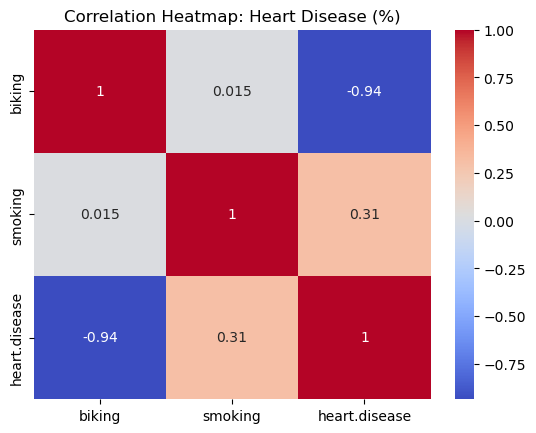

In [24]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap= "coolwarm", annot= True)
plt.title("Correlation Heatmap: Heart Disease (%)", fontsize=12, fontweight='bold')
plt.show()

### Linear Regression Model

In [12]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Validiation of Assumptions

In [13]:
predictions = regression_model.predict(X_train)
residuals = y_train - predictions

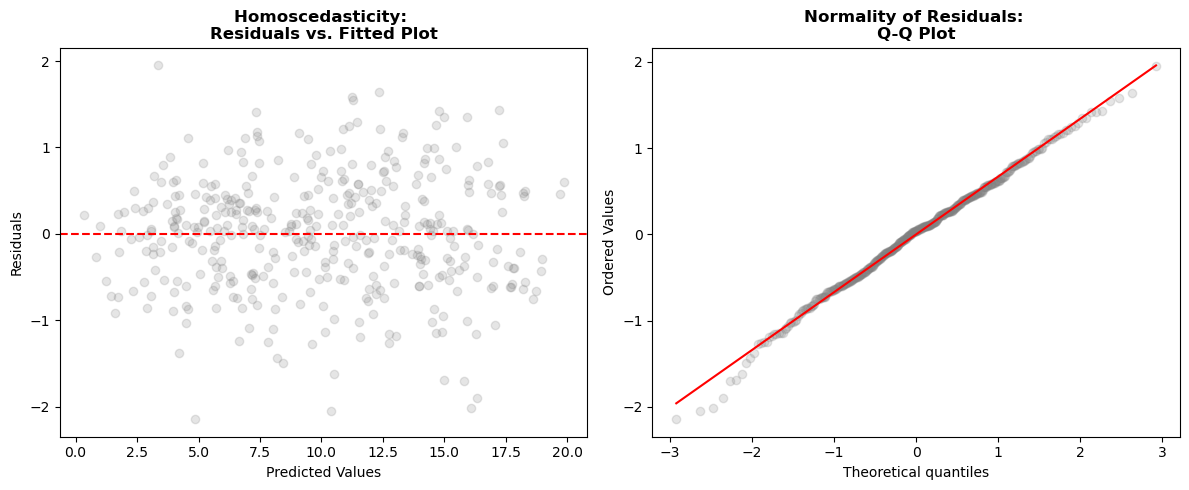

In [27]:
#to prove homoscedasticity (constant variance of residuals) and normality of residuals
fig, ax = plt.subplots(1, 2, figsize= (12, 5))


ax[0].scatter(predictions, residuals, alpha=0.2, color = 'grey')
ax[0].axhline(y=0, color = 'red', linestyle='--')
ax[0].set_xlabel('Predicted Values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Homoscedasticity: \nResiduals vs. Fitted Plot', fontsize=12, fontweight='bold')


stats.probplot(residuals, dist=stats.norm, plot= ax[1])
ax[1].set_title("Normality of Residuals: \nQ-Q Plot", fontsize=12, fontweight='bold')
qq = ax[1].get_lines()
qq[0].set_color('grey')
qq[0].set_alpha(0.2)
plt.tight_layout()
plt.show()

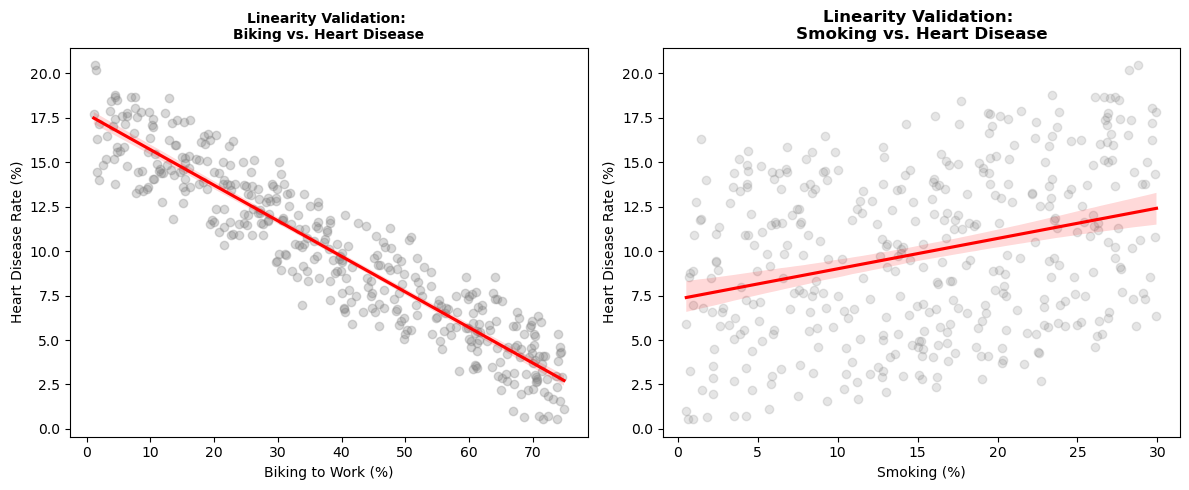

In [28]:
# proving linearity

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x=X_train['biking'], 
            y=y_train, ax=ax[0], 
            scatter_kws={'alpha':0.3, 'color':'grey'}, 
            line_kws={'color':'red'})
ax[0].set_title('Linearity Validation: \nBiking vs. Heart Disease', fontsize=10, fontweight='bold')
ax[0].set_xlabel('Biking to Work (%)')
ax[0].set_ylabel('Heart Disease Rate (%)')

sns.regplot(x = X_train['smoking'], 
            y = y_train, 
            ax = ax[1], 
            scatter_kws={'alpha':0.2, 'color':'grey'}, 
            line_kws={'color':'red'})
ax[1].set_title('Linearity Validation: \nSmoking vs. Heart Disease', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Smoking (%)')
ax[1].set_ylabel('Heart Disease Rate (%)')

plt.tight_layout()
plt.show()

In [16]:

# independence of errors
durbin_watson = durbin_watson(residuals)
print(f"Durbin-Watson score: {durbin_watson:.4f}")

# data does not violate any assumptions

Durbin-Watson score: 2.2422


#### Model Coefficient Evaluation

$$\text{Heart Disease (\%)} = \beta_0 + (\beta_1 \times \text{Biking to Work (\%)}) + (\beta_2 \times \text{Smoking (\%)})$$

In [19]:
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)


linear_model = sm.OLS(y_train, X_train_ols).fit()  # Fitting the OLS model

In [20]:
print(f"Intercept (Beta 0): {regression_model.intercept_:.4f}\n")
print(f"Coefficient (Beta 1): {regression_model.coef_[0]:.4f}\n")
print(f"Coefficient (Beta 2): {regression_model.coef_[1]:.4f}\n")

Intercept (Beta 0): 15.0492

Coefficient (Beta 1): -0.2008

Coefficient (Beta 2): 0.1761



In [21]:
print(linear_model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.0492      0.092    163.775      0.000      14.869      15.230
biking        -0.2008      0.002   -129.434      0.000      -0.204      -0.198
smoking        0.1761      0.004     44.087      0.000       0.168       0.184


#### Performance Evaluation & Error Metrics

In [33]:
y_pred_test = regression_model.predict(X_test)


mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test) 
r2_test = r2_score(y_test, y_pred_test)


print(f"Mean Squared Error (MSE):  {mse_test:.4f}%")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}%")
print(f"R2: {r2_test*100:.4f}")

coefficients = regression_model.coef_
intercept = regression_model.intercept_


Mean Squared Error (MSE):  0.3436%
Root Mean Squared Error (RMSE): 0.5862%
r2_test: 97.9981


### Summary

##### In an imaginary sample of 500 towns, every 1 % increase of people biking to work each day, the percentage of people with heart disease is estimated to decrease by -0.2 %, all other variables held constant.  It is with 95% confidence, for every 1% increase of people biking to work, the decrease in heart disease rate falls between 0.204% and 0.198 %, holding all other variables constant.  A p-value of < 0.01 (p-value = 0.0) proves variable to be a statistically significant predictor to the model.


##### In an imaginary sample of 500 towns, with every 1 % increase of people smoking, the percentage of people with heart disease is estimated to increase by 0.17 %, all other variables held constant.  It is with 95% confidence, for every 1% increase of people smoking, the increase in heart disease rate falls between 0.168 % and 0.184 %, holding all other variables constant.  A p-value of < 0.01 (p-value = 0.0) proves variable to be statistically significant predictor to the model.

##### An RMSE of 0.58% indicates small error margin; a capable predictive model with high precision. Its independent variables, smoking (%) and biking to work (%), explain 98.0% of the total variance (**$R^2$ = 0.9800) in heart disease rates.